In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# using 'Science' style plots
plt.style.use(['science', 'high-vis'])

J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

In [3]:
def build_L(N, num_dimers=1, output=False):
    # building matrices
    H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)]) else 0)
    V = sp.Matrix(N, N, lambda i,j : epsilon*sp.Symbol(f"epsilon_{min(i,j)}{max(i,j)}", real=True, positive=True) 
                  if ({i,j} not in [{2*k, 2*k+1} for k in range(num_dimers)] and i!=j) else 0)

    if output: display(H0+V)
    
    # building lindblad jump operators
    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    
    # building lindbladians
    L, rho = lindbladian(N, output=False, degenerate=False, H=H0+V, L_operators=L_operators)

    # setting all dephasing constants to the same constant gamma
    L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})

    return L, rho


In [35]:
def randomize(N, num_dimers, matrix, seed=-1, low=1, high=10):
    rng = np.random.default_rng(seed=seed) if seed != -1 else np.random.default_rng()

    epsilonij_val = { sp.Symbol(f"epsilon_{min(i,j)}{max(i,j)}", real=True, positive=True):rng.uniform(low,high)
  for i in range(N) for j in range(i) 
  if ({i,j} not in [{2*k, 2*k+1} for k in range(num_dimers)] and i!=j) }

    return matrix.subs(epsilonij_val), epsilonij_val

In [18]:
def find_liousvillian_gap(matrix, atol=1e-17):
    # if converting to numpy just in case:
    matrix = np.array(matrix).astype(complex)
    
    # finding evals and evecs
    evals, evecs = np.linalg.eig(matrix)

    # uses a mask to eliminate the 0 eigenvalue (may have to adjust tolerance),
    # then finds the min of the magnitudes of the real parts of the non-zero evals
    return np.min(np.abs(np.real(evals)[~np.isclose(np.real(evals),np.zeros(np.shape(matrix)[0]), atol=atol)]))

In [327]:
def gaps_of_liousvillian(iterations=3, N=3, num_dimers=1, J_val=0.1, gamma_val=1e-6, epsilon_val=1e-4, seed=-1, low=1, high=10):
    print(f"Starting N={N}: ", end="")
    
    # generating our seeds that we will use for each iteration
    rng = np.random.default_rng(seed=seed) if seed != -1 else np.random.default_rng()
    seeds = rng.integers(1e3, size=iterations)

    gaps = []

    # building the Linbladian
    L, rho = build_L(N, num_dimers=num_dimers)
    # plugging in our known vals
    L = L.subs({J:J_val, gamma:gamma_val, epsilon: epsilon_val})
    
 
    # iterating through each seed and computing the liousvillian gap
    for i in range(iterations):
        print(i, end=", ")

        # randomizing L
        L_random, epsilonij_val = randomize(N, num_dimers, L, seed=seeds[i], low=low, high=high)
        gaps.append(find_liousvillian_gap(L_random))
    
    print()

    
    return gaps





    

Starting N=3: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 
Starting N=4: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,

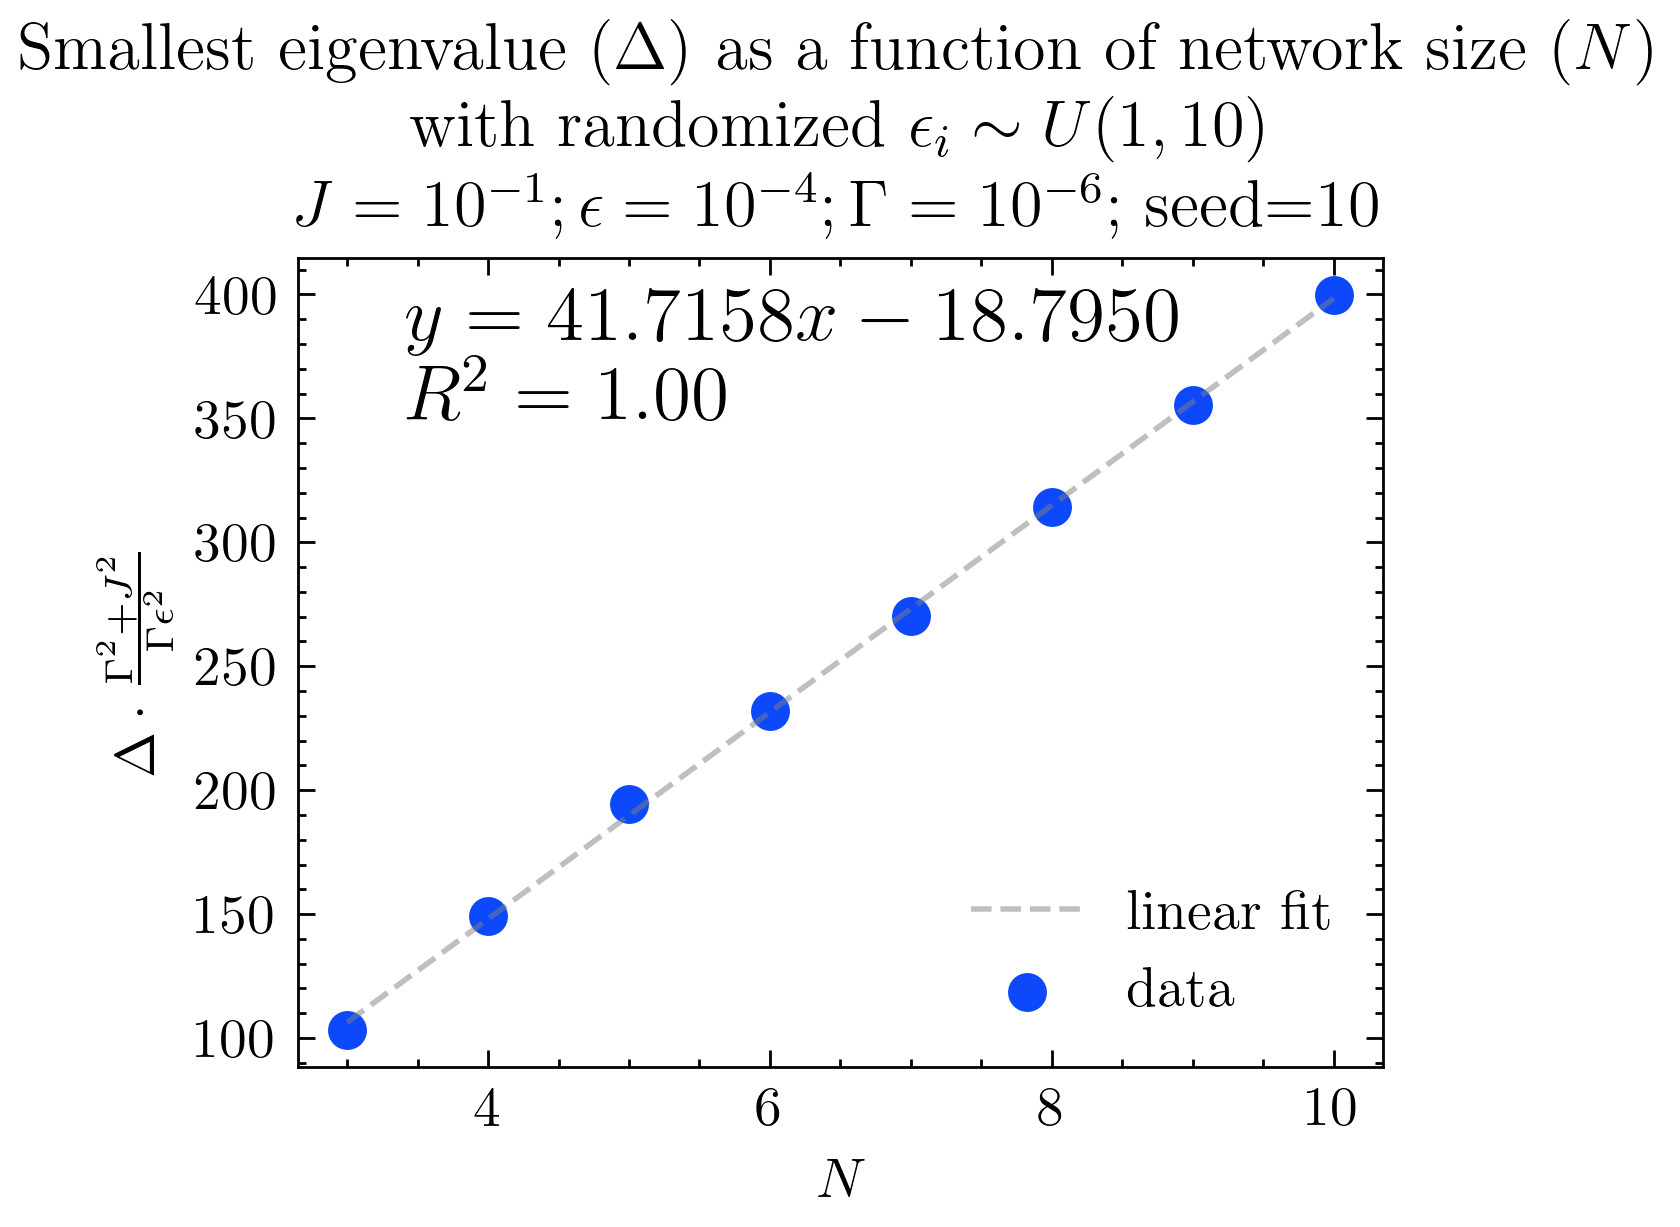

In [381]:
# NETWORK PARAMETERS
J_val = 0.1
epsilon_val = 1e-4
gamma_val = 1e-6
seed = 10
num_dimers = 1
high = 10
low = 1

# SIMULATION PARAMETERS
N_start = 3
N_stop = 10
iterations_per_N = 200

gaps = np.asarray([ gaps_of_liousvillian(iterations=iterations_per_N,
                                         N=i, 
                                         num_dimers=num_dimers, 
                                         J_val=J_val, 
                                         gamma_val=gamma_val, 
                                         epsilon_val=epsilon_val, 
                                         seed=seed,
                                         high=high,
                                         low=low,
                                ) 
         for i in range(N_start, N_stop+1) ]
)

Ns = np.arange(N_start, N_stop+1)



# PLOTTING

# linear regression of the form: y=mx+b
m, b, r_value, p_value, std_err = scipy.stats.linregress(   Ns, np.mean(gaps, axis=1) / (2 * gamma_val * epsilon_val**2 / (gamma_val**2 + J_val**2))   )
plt.plot(Ns,m*Ns+b, color="gray", linestyle="--", alpha=0.5, label="linear fit")
plt.annotate(fr"$y={np.real(m):.4f}x{"+" if np.real(b)>0 else "-"}{np.abs(b):.4f}$"+ "\n" + fr"$R^2 = {np.real(r_value)**2:.2f}$",
                     (0.1,0.8),
                     xycoords="axes fraction",
                     fontsize="14",
                     ha="left"
                    )
# data
plt.scatter(Ns, np.mean(gaps, axis=1) / (2 * gamma_val * epsilon_val**2 / (gamma_val**2 + J_val**2)), label="data")

plt.xlabel(r"$N$")
plt.ylabel(r"$ \Delta \cdot \frac{ \Gamma^2 + J^2 }{\Gamma \epsilon^2}$")
plt.title(r"Smallest eigenvalue ($\Delta$) as a function of network size ($N$) " + "\n" + rf" with randomized $\epsilon_i \sim U({{{low}}}, {{{high}}})$" + "\n" + rf"$J=10^{{{int(np.log10(J_val))}}}; \epsilon=10^{{{int(np.log10(epsilon_val))}}}; \Gamma=10^{{{int(np.log10(gamma_val))}}}$; seed={{{seed}}}")
plt.legend()


In [384]:
plt.savefig("plot")

<Figure size 1400x1050 with 0 Axes>